# V0.3 — Conservation under composition & composite-OOD detection

**Tier 0 / Verification Protocol §V0.3.** Targets architecture **Decisions #12 & #14** and Part IV's universal pattern *gather → stage into buses → reduce → commit*. This validates the *operator-composition* pillar (V0.1/V0.2 validated the homogenization pillar).

### Claims (falsifiable)
1. **Conservation under composition (theorem-check).** With the four fire operators (pyrolysis, combustion, conduction, char-weakening) composed *only* by staging additive contributions into conserved buses, every bus (energy, mass, O₂, charge) audits to ≈0 in-distribution.
2. **Composite-OOD detection (empirical).** A composite off-distribution event — an ignited fuel-rich/O₂-poor pocket (lightning heat + charge) driving a one-step runaway — spikes a **residual** that flags it *even when every operator's own validity envelope reports "in distribution."* The audit catches the cross-operator/shared-bus effect that per-operator marginal checks miss.

### Oracle (independent ground truth)
The **monolithic coupled reference integrator** (`monolithic_fire.py`, adaptive sub-stepped RK4 — no operator splitting), itself validated against scipy's stiff solver. It resolves the stiff contention correctly (rates self-limit as O₂→0), so the split runtime's residual spike is provably a *splitting artifact*, not physics.

### Two monitors, side by side
- **Conservation audit** (primary): per-bus `|committed Δtotal − ledgered transfer| / gross flow`. ≈0 in-distribution; spikes when a runaway over-subscribes a shared bus and the commit must clamp (breaking energy↔mass stoichiometry).
- **Split-vs-monolithic divergence** (the governing-residual reading, realized against the oracle): one-step `‖U_split − U_monolithic‖`. ≈0 in-distribution; spikes when the split scheme can't track the coupled truth.

### Pre-registered pass criteria (frozen)
| # | Metric | Threshold | Failure → outcome |
|---|---|---|---|
| 1 | in-distribution per-bus residual | **< 1e-6** of throughput, every bus & step | **KILL/REDESIGN** bus/ledger |
| 2 | both monitors detect the composite OOD | **0 false negatives** over the sweep, with per-operator envelopes missing it in **≥1** case | **REDESIGN** monitor |

Detection threshold per monitor = **10× its in-distribution band**.

In [1]:
"""(1) Setup — imports, frozen constants, fire model + monolithic oracle."""
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))

import fire_operators as fo
import bus_runtime as br
import monolithic_fire as mf

np.set_printoptions(precision=4, suppress=True)
np.random.seed(0)

# ---- PRE-REGISTERED constants (frozen) ----
N            = 16             # 3-D voxel field (reuses the V0.1 grid convention)
DT           = 1.0e-3         # production timestep (gentle in-distribution: no clamp)
N_BURN       = 200            # in-distribution burn steps
CONS_TOL     = 1e-6           # criterion 1: per-bus residual < 1e-6 of throughput
DETECT_MULT  = 10.0          # detection threshold = 10x in-distribution band
P            = fo.FireParams()

# per-field scale for the split-vs-monolithic divergence (monitor 2)
SCALE = {"T": 300.0, "m_s": 1.0, "gas": 1.0, "o2": 0.23, "char": 1.0, "q": 1.0}

def divergence(old, dt):
    """One-step ||U_split - U_monolithic|| (scaled) — monitor 2, vs the oracle."""
    sp, _, _, _ = br.step_split({k: v.copy() for k, v in old.items()}, P, dt)
    mo, _ = mf.step_monolithic({k: v.copy() for k, v in old.items()}, P, dt)
    s = sum(float(np.sum(((sp[f] - mo[f]) / SCALE[f]) ** 2)) for f in br.FIELDS)
    return float(np.sqrt(s))

print(f"grid N={N} ({N**3} cells), dt={DT}, burn steps={N_BURN}")
print(f"envelopes:  pyrolysis T{P.py_T}   combustion T{P.cb_T}")


grid N=16 (4096 cells), dt=0.001, burn steps=200
envelopes:  pyrolysis T(300.0, 900.0)   combustion T(400.0, 1400.0)


## (2) Validate the oracle *before trusting it*

The monolithic integrator is only ground truth if it is correct: (a) on the 0-D coupled ODE it must match scipy's stiff Radau solver; (b) with combustion off, pyrolysis must conserve solid+gas+char mass exactly.

In [2]:
"""(2) Oracle validation: monolithic vs scipy (0-D) + pyrolysis mass conservation."""
from scipy.integrate import solve_ivp

st0 = {"T": np.array([[[800.0]]]), "m_s": np.array([[[1.0]]]),
       "gas": np.array([[[0.3]]]), "o2": np.array([[[0.5]]]),
       "char": np.array([[[0.0]]]), "q": np.array([[[0.2]]])}
T_end = 0.02
mine, _ = mf.step_monolithic({k: v.copy() for k, v in st0.items()}, P, T_end)

def rhs(t, y):
    s = {f: np.array([[[y[i]]]]) for i, f in enumerate(br.FIELDS)}
    F = fo.coupled_rhs(s, P)
    return [F[f].item() for f in br.FIELDS]
sol = solve_ivp(rhs, [0, T_end], [st0[f].item() for f in br.FIELDS],
                method="Radau", rtol=1e-9, atol=1e-12)
ode_err = max(abs(mine[f].item() - sol.y[i, -1]) / (abs(sol.y[i, -1]) + 1e-9)
              for i, f in enumerate(br.FIELDS))
print(f"2a) monolithic vs scipy Radau (0-D coupled ODE): max rel err = {ode_err:.2e}")

P_noc = fo.FireParams(A_cb=0.0, h_loss=0.0, o2_influx=0.0)
stm = br.make_state(8, T0=760.0, gas0=0.05, o2=0.2)
M0 = (stm["m_s"] + stm["gas"] + stm["char"]).sum()
stf, _ = mf.step_monolithic(stm, P_noc, 0.01)
mass_err = abs((stf["m_s"] + stf["gas"] + stf["char"]).sum() - M0) / M0
print(f"2b) pyrolysis-only solid mass conservation: |dM|/M = {mass_err:.2e}")

ORACLE_OK = (ode_err < 1e-4) and (mass_err < 1e-12)
print(f"\n   => ORACLE TRUSTWORTHY: {ORACLE_OK}")
assert ORACLE_OK, "monolithic oracle failed self-validation — halt."


2a) monolithic vs scipy Radau (0-D coupled ODE): max rel err = 2.48e-05
2b) pyrolysis-only solid mass conservation: |dM|/M = 0.00e+00

   => ORACLE TRUSTWORTHY: True


## (3) In-distribution burn → Metric 1 (conservation) + monitor bands

Ignite a hot core in a fuel/O₂ bed and run the split conserved-bus runtime. Audit every bus each step; also record both monitors each step to establish their **in-distribution bands** (the noise floor the OOD spike must clear). Confirm every operator's envelope stays green throughout.

In [3]:
"""(3) In-distribution burn: audit all buses + record monitor bands."""
c = slice(N // 2 - 2, N // 2 + 2)
st = br.make_state(N, T0=500.0, gas0=0.05, o2=0.23)
st["T"][c, c, c] = 760.0                    # ignition

bus_res = {b: [] for b in ("energy", "mass", "o2", "charge")}
div_band = []
env_all_green = True
for n in range(N_BURN):
    div_band.append(divergence(st, DT))     # monitor 2 noise floor (vs oracle)
    env = fo.envelopes(st, P)
    env_all_green &= all(bool(v.all()) for v in env.values())
    st, led, audit, gov = br.step_split(st, P, DT)
    for b in bus_res:
        bus_res[b].append(audit[b])

bus_res = {b: np.array(v) for b, v in bus_res.items()}
audit_band = max(arr.max() for arr in bus_res.values())
div_band = np.array(div_band); div_band_max = div_band.max()

print("in-distribution per-bus max residual:")
for b, v in bus_res.items():
    print(f"   {b:7s} max = {v.max():.2e}")
print(f"\nmonitor in-distribution bands:  audit = {audit_band:.2e}   "
      f"split-vs-monolithic = {div_band_max:.2e}")
print(f"all operator envelopes green throughout burn: {env_all_green}")

METRIC1_PASS = audit_band < CONS_TOL
AUDIT_THRESH = DETECT_MULT * audit_band
DIV_THRESH = DETECT_MULT * div_band_max
print(f"\n   => METRIC 1 (conservation < {CONS_TOL:.0e}) PASS: {METRIC1_PASS}")
print(f"   detection thresholds: audit > {AUDIT_THRESH:.2e}, divergence > {DIV_THRESH:.2e}")


in-distribution per-bus max residual:
   energy  max = 5.35e-11
   mass    max = 4.16e-12
   o2      max = 5.28e-12
   charge  max = 0.00e+00

monitor in-distribution bands:  audit = 5.35e-11   split-vs-monolithic = 3.62e-03
all operator envelopes green throughout burn: True

   => METRIC 1 (conservation < 1e-06) PASS: True
   detection thresholds: audit > 5.35e-10, divergence > 3.62e-02


## (4) Composite-OOD sweep → Metric 2 (detection vs envelope blind-spot)

Each event is an **ignited fuel-rich / O₂-poor pocket** (a lightning heat + charge deposit on accumulated volatiles) — a genuinely composite state. We sweep the core temperature from **stealth** (`T ≤ 900`, inside *every* operator's envelope) to **extreme** (`T > 900`, where envelopes do flag). For each: one split step → both monitors; and each operator's envelope status. The claim: both monitors detect **all** events (0 false negatives) while the per-operator envelopes miss the stealth ones (necessity of the audit).

In [4]:
"""(4) OOD sweep: construct ignited fuel-rich pockets, test both monitors + envelopes."""
def ood_event(T_core, gas_core=15.0, o2_core=0.03, q_core=1.0, loc=c):
    st = br.make_state(N, T0=520.0, gas0=0.05, o2=0.23)
    st["T"][loc, loc, loc] = float(T_core)
    st["gas"][loc, loc, loc] = gas_core
    st["o2"][loc, loc, loc] = o2_core
    st["q"][loc, loc, loc] = q_core
    return st

# sweep: core temperature (stealth <=900 -> extreme), plus a couple of location/richness variants
sweep = [("T=850 stealth", ood_event(850)),
         ("T=900 stealth", ood_event(900)),
         ("T=880 richer",  ood_event(880, gas_core=25.0, o2_core=0.02)),
         ("T=1050",        ood_event(1050)),
         ("T=1300",        ood_event(1300)),
         ("T=1500",        ood_event(1500)),
         ("T=920 offset",  ood_event(920, loc=slice(2, 6)))]

rows = []
for label, st_e in sweep:
    _, _, audit, _ = br.step_split({k: v.copy() for k, v in st_e.items()}, P, DT)
    a = br.max_audit(audit); d = divergence(st_e, DT)
    env = fo.envelopes(st_e, P)
    env_flags = {k: bool(v.all()) for k, v in env.items()}     # True = green (in-dist)
    all_green = all(env_flags.values())
    rows.append(dict(label=label, audit=a, div=d, all_green=all_green,
                     det_a=a > AUDIT_THRESH, det_d=d > DIV_THRESH,
                     env_flagged=not all_green))

print(f"{'event':16s} {'audit':>10} {'divergence':>11} {'env_green':>10} "
      f"{'detect_audit':>13} {'detect_div':>11}")
for r in rows:
    print(f"{r['label']:16s} {r['audit']:>10.2e} {r['div']:>11.2e} "
          f"{str(r['all_green']):>10} {str(r['det_a']):>13} {str(r['det_d']):>11}")

fn_audit = sum(not r["det_a"] for r in rows)        # false negatives, monitor 1
fn_div = sum(not r["det_d"] for r in rows)          # false negatives, monitor 2
n_env_blind = sum(r["all_green"] for r in rows)     # cases all envelopes miss (necessity)

print(f"\nfalse negatives: audit={fn_audit}, divergence={fn_div}  (need 0 each)")
print(f"events all per-operator envelopes MISS (all green): {n_env_blind}  (need >=1)")
METRIC2_PASS = (fn_audit == 0) and (fn_div == 0) and (n_env_blind >= 1)
print(f"\n   => METRIC 2 (detection, necessity) PASS: {METRIC2_PASS}")


event                 audit  divergence  env_green  detect_audit  detect_div
T=850 stealth      3.68e-01    2.78e-01       True          True        True
T=900 stealth      5.99e-01    3.63e-01       True          True        True
T=880 richer       7.11e-01    3.90e-01       True          True        True
T=1050             8.67e-01    1.43e+00      False          True        True
T=1300             9.63e-01    6.95e+00      False          True        True
T=1500             9.82e-01    2.76e+01      False          True        True
T=920 offset       6.61e-01    4.44e-01      False          True        True

false negatives: audit=0, divergence=0  (need 0 each)
events all per-operator envelopes MISS (all green): 3  (need >=1)

   => METRIC 2 (detection, necessity) PASS: True


## (5) Plots

(a) in-distribution per-bus residuals flatlined at machine-epsilon; (b) the OOD sweep — both monitors clearing threshold while the stealth events are envelope-green; (c) split vs monolithic agree in-distribution (the oracle the OOD spike is measured against).

saved figure -> /workspace/nebula/verification_notebooks/phase0/results/V0_3_conservation_composite_ood.png


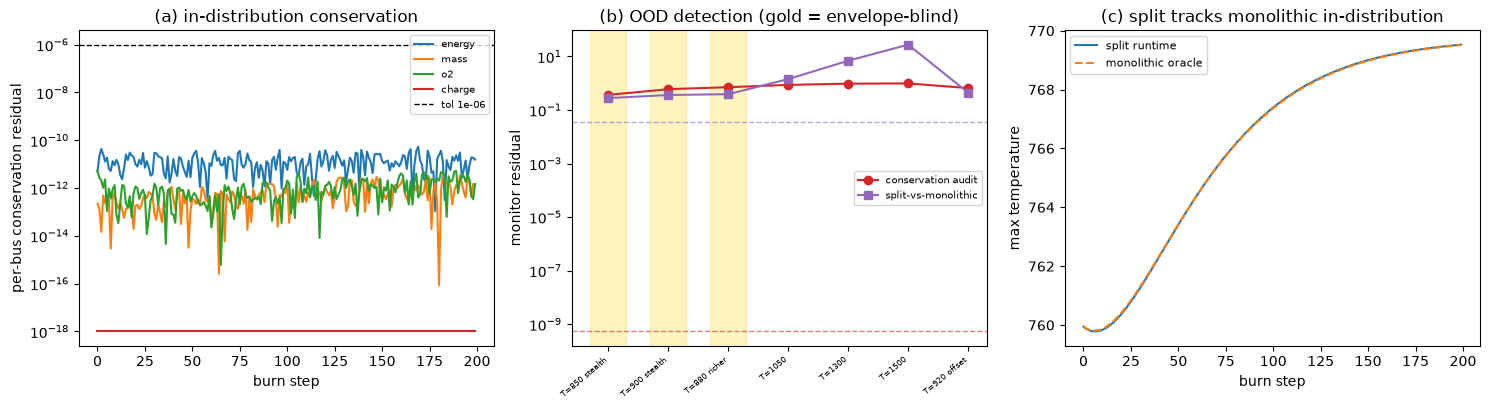

In [5]:
"""(5) Figures."""
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) in-distribution per-bus residual trajectories
for b, v in bus_res.items():
    ax[0].semilogy(np.maximum(v, 1e-18), label=b)
ax[0].axhline(CONS_TOL, ls="--", color="k", lw=1, label=f"tol {CONS_TOL:.0e}")
ax[0].set_xlabel("burn step"); ax[0].set_ylabel("per-bus conservation residual")
ax[0].set_title("(a) in-distribution conservation"); ax[0].legend(fontsize=7)

# (b) OOD sweep: both monitors vs thresholds, marker = envelope-green (stealth)
x = np.arange(len(rows))
au = [r["audit"] for r in rows]; dv = [r["div"] for r in rows]
green = [r["all_green"] for r in rows]
ax[1].semilogy(x, au, "o-", color="tab:red", label="conservation audit")
ax[1].semilogy(x, dv, "s-", color="tab:purple", label="split-vs-monolithic")
ax[1].axhline(AUDIT_THRESH, ls="--", color="tab:red", lw=1, alpha=0.6)
ax[1].axhline(DIV_THRESH, ls="--", color="tab:purple", lw=1, alpha=0.6)
for i, g in enumerate(green):                       # mark envelope-blind (stealth) events
    if g:
        ax[1].axvspan(i - 0.3, i + 0.3, color="gold", alpha=0.25)
ax[1].set_xticks(x); ax[1].set_xticklabels([r["label"] for r in rows], rotation=40, ha="right", fontsize=6)
ax[1].set_ylabel("monitor residual"); ax[1].legend(fontsize=7)
ax[1].set_title("(b) OOD detection (gold = envelope-blind)")

# (c) split vs monolithic in-distribution (same IC) — T_max trajectory overlay
st_s = br.make_state(N, T0=500.0, gas0=0.05, o2=0.23); st_s["T"][c, c, c] = 760.0
st_m = {k: v.copy() for k, v in st_s.items()}
tmax_s, tmax_m = [], []
for n in range(N_BURN):
    st_s, _, _, _ = br.step_split(st_s, P, DT); tmax_s.append(st_s["T"].max())
    st_m, _ = mf.step_monolithic(st_m, P, DT);  tmax_m.append(st_m["T"].max())
ax[2].plot(tmax_s, label="split runtime")
ax[2].plot(tmax_m, "--", label="monolithic oracle")
ax[2].set_xlabel("burn step"); ax[2].set_ylabel("max temperature")
ax[2].set_title("(c) split tracks monolithic in-distribution"); ax[2].legend(fontsize=8)

fig.tight_layout()
outdir = REPO / "verification_notebooks" / "phase0" / "results"
outdir.mkdir(exist_ok=True)
fig.savefig(outdir / "V0_3_conservation_composite_ood.png", dpi=110)
print(f"saved figure -> {outdir / 'V0_3_conservation_composite_ood.png'}")
plt.show()


In [6]:
"""(6) Frozen verdict."""
def verdict(name, passed, detail, outcome):
    print(f"  [{'OK ' if passed else 'XX '}] {name:32s} {'PASS' if passed else f'FAIL -> {outcome}'}")
    print(f"        {detail}")

print("=" * 76)
print("V0.3 — CONSERVATION UNDER COMPOSITION & COMPOSITE-OOD DETECTION — VERDICT")
print("=" * 76)
verdict("1. conservation (< 1e-6)", METRIC1_PASS,
        f"in-distribution max bus residual = {audit_band:.1e}; envelopes green = {env_all_green}",
        "KILL/REDESIGN bus+ledger")
verdict("2. composite-OOD detection", METRIC2_PASS,
        f"false negatives: audit={fn_audit}, divergence={fn_div}; "
        f"{n_env_blind} events all-envelope-green yet detected (necessity)",
        "REDESIGN monitor")
verdict("(aux) oracle self-validated", ORACLE_OK,
        f"0-D vs scipy {ode_err:.1e}; pyrolysis mass {mass_err:.1e}", "halt")

ALL_PASS = METRIC1_PASS and METRIC2_PASS and ORACLE_OK
print("=" * 76)
print(f"  V0.3 OVERALL: {'PASS — conserved-bus composition is correct; the audit is the' if ALL_PASS else 'FAIL — see outcome class above'}")
if ALL_PASS:
    print("                primary composite-OOD monitor (catches what per-operator envelopes miss)")
print("=" * 76)


V0.3 — CONSERVATION UNDER COMPOSITION & COMPOSITE-OOD DETECTION — VERDICT
  [OK ] 1. conservation (< 1e-6)         PASS
        in-distribution max bus residual = 5.3e-11; envelopes green = True
  [OK ] 2. composite-OOD detection       PASS
        false negatives: audit=0, divergence=0; 3 events all-envelope-green yet detected (necessity)
  [OK ] (aux) oracle self-validated      PASS
        0-D vs scipy 2.5e-05; pyrolysis mass 0.0e+00
  V0.3 OVERALL: PASS — conserved-bus composition is correct; the audit is the
                primary composite-OOD monitor (catches what per-operator envelopes miss)
